# 7. Penentuan Jumlah Cluster Optimal pada K-Means Clustering

Tahapan ini bertujuan menentukan nilai *k* (jumlah cluster) yang paling optimal
untuk mengelompokkan lokasi-lokasi pengamatan berdasarkan karakteristik fitur
deret waktu polutan **CO**, **NO2**, dan **SO2** yang telah diekstraksi pada tahap sebelumnya.

**Hal-hal yang dilakukan pada notebook ini:**

1. Mereduksi dimensi data 68 fitur menggunakan **PCA** menjadi **37 komponen utama**.
2. Mencari nilai *k* terbaik melalui **Elbow Method** dan **Silhouette Score**
   pada ruang dimensi PCA.
3. Mengukur apakah data memiliki kecenderungan alami untuk membentuk kelompok
   menggunakan **Hopkins Statistic**.
4. Menjalankan analisis yang sama pada **68 fitur asli tanpa reduksi dimensi**
   untuk dibandingkan hasilnya.
5. Merangkum perbandingan dari kedua pendekatan tersebut untuk ketiga polutan.

> **Catatan:** File `ekstraksi_fitur_co.csv`, `ekstraksi_fitur_no2.csv`, dan
> `ekstraksi_fitur_so2.csv` merupakan data fitur hasil ekstraksi TSFEL dari
> seluruh lokasi pengamatan kelas (37 titik lokasi, masing-masing 68 fitur numerik).
> Notebook ini bekerja pada level fitur, bukan sinyal mentah.


## 1. Landasan Teori


### 1.1 Principal Component Analysis (PCA)

PCA digunakan untuk menyederhanakan data berdimensi tinggi dengan
menemukan arah-arah (komponen) yang paling banyak menjelaskan variansi data.
Komponen-komponen ini bersifat ortogonal (tidak berkorelasi satu sama lain)
dan disusun dari yang paling informatif ke yang paling sedikit.

Secara matematis, PCA memecahkan persamaan nilai eigen dari matriks kovarians
data yang telah distandarisasi $\Sigma$:

$$\Sigma v_i = \lambda_i v_i$$

di mana $v_i$ adalah komponen utama ke-$i$ dengan $\lambda_i$ sebagai nilai variansi
yang diwakilinya. Komponen dengan $\lambda_i$ terbesar diprioritaskan karena membawa
informasi paling banyak.

Sebelum PCA diterapkan, data perlu **distandarisasi** terlebih dahulu.
Ini karena fitur-fitur TSFEL memiliki rentang nilai yang sangat berbeda satu sama lain
(misalnya `abs_energy` bisa ratusan kali lebih besar dari `entropy`).
Tanpa standardisasi, PCA akan bias ke fitur dengan skala terbesar.


### 1.2 K-Means Clustering

K-Means merupakan algoritma clustering yang membagi data ke dalam $k$ kelompok
dengan cara meminimalkan **Within-Cluster Sum of Squares (WCSS)** atau yang biasa
disebut **inertia** — yaitu total kuadrat jarak setiap titik data ke pusat (centroid)
cluster-nya:

$$J = \sum_{j=1}^{k} \sum_{x_i \in C_j} \lVert x_i - \mu_j \rVert^2$$

Semakin kecil nilai inertia, semakin rapat titik-titik dalam satu cluster.
Namun, penambahan $k$ selalu menurunkan inertia — sehingga diperlukan metode
tambahan untuk menemukan $k$ yang benar-benar optimal.


### 1.3 Cara Menentukan Jumlah Cluster Optimal

Dua metode yang digunakan dalam analisis ini:

- **Elbow Method**: Grafik inertia vs. $k$ divisualisasikan. Ketika penurunan
  inertia mulai melambat secara signifikan membentuk "siku", titik tersebut
  menjadi kandidat $k$ yang baik. Namun metode ini bersifat subjektif dan
  tidak selalu menghasilkan siku yang jelas.

- **Silhouette Score**: Untuk setiap titik data $i$, dihitung seberapa
  baik titik tersebut cocok di cluster-nya sendiri dibandingkan cluster lain:

$$s(i) = \frac{b(i) - a(i)}{\max(a(i), b(i))}$$

  $a(i)$ adalah rata-rata jarak ke titik lain dalam cluster yang sama,
  sedangkan $b(i)$ adalah rata-rata jarak ke titik-titik di cluster tetangga terdekat.
  Nilai silhouette berkisar antara $-1$ hingga $1$ — semakin tinggi semakin baik.
  Metode ini lebih objektif dan digunakan sebagai **penentu utama** $k$ optimal.


### 1.4 Hopkins Statistic

Sebelum memutuskan berapa cluster yang digunakan, ada pertanyaan yang lebih fundamental:
**apakah data ini memang punya struktur kelompok alami, ataukah titik-titiknya tersebar
secara acak di ruang fitur?**

Hopkins Statistic menjawab pertanyaan ini dengan membandingkan dua hal:
- $u_i$: jarak setiap titik data asli ke titik terdekatnya di antara data asli
- $w_i$: jarak titik-titik acak (yang dibangkitkan secara uniform) ke data asli terdekat

$$H = \frac{\sum w_i}{\sum u_i + \sum w_i}$$

**Cara membaca hasilnya:**
- $H \approx 0.5$ → data tersebar acak, tidak ada kluster alami
- $H$ mendekati **1** → data terkluster dengan baik, ada pengelompokan yang nyata
- $H$ mendekati **0** → data tersusun sangat teratur (hampir tidak terjadi pada data dunia nyata)


## 2. Pemuatan dan Pemeriksaan Data

Ketiga file CSV memiliki struktur yang sama: tiga kolom identitas
(`id`, `nama`, `daerah`) diikuti 68 kolom nilai fitur TSFEL numerik.
Pada tahap ini diperiksa dimensi data, keberadaan nilai kosong (NaN),
serta fitur yang nilainya konstan di semua baris — fitur konstan tidak berkontribusi
dalam proses clustering dan dapat menyebabkan masalah saat standardisasi.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.neighbors import NearestNeighbors
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 110
np.random.seed(42)

FILES = {
    'CO':  '../data/ekstraksi_fitur_co.csv',
    'NO2': '../data/ekstraksi_fitur_no2.csv',
    'SO2': '../data/ekstraksi_fitur_so2.csv',
}

raw = {}
for name, path in FILES.items():
    df = pd.read_csv(path)
    raw[name] = df
    print(f'--- {name} ---')
    print(f'  Jumlah baris (sampel/lokasi) : {df.shape[0]}')
    print(f'  Jumlah kolom fitur           : {df.shape[1] - 3}  (di luar id, nama, daerah)')
    print(f'  Total nilai NaN              : {df.isna().sum().sum()}')
    print()


--- CO ---
  Jumlah baris (sampel/lokasi) : 37
  Jumlah kolom fitur           : 68  (di luar id, nama, daerah)
  Total nilai NaN              : 0

--- NO2 ---
  Jumlah baris (sampel/lokasi) : 37
  Jumlah kolom fitur           : 68  (di luar id, nama, daerah)
  Total nilai NaN              : 0

--- SO2 ---
  Jumlah baris (sampel/lokasi) : 37
  Jumlah kolom fitur           : 68  (di luar id, nama, daerah)
  Total nilai NaN              : 0



## 3. Preprocessing

Beberapa langkah persiapan data dilakukan sebelum memasuki tahap analisis:

1. **Isolasi fitur**: Kolom `id`, `nama`, dan `daerah` dipisahkan — hanya
   68 kolom fitur numerik yang digunakan.
2. **Imputasi NaN**: Nilai kosong diisi dengan **median** kolom masing-masing.
   Median dipilih karena lebih tahan terhadap nilai ekstrem dibandingkan mean,
   mengingat beberapa fitur spektral TSFEL cenderung memiliki distribusi miring.
3. **Eliminasi fitur konstan**: Fitur yang nilainya sama di semua baris dibuang
   karena tidak memberikan informasi pembeda dan dapat membuat standardisasi
   menjadi tidak terdefinisi (pembagian dengan nol).
4. **Standardisasi z-score**: Setiap fitur ditransformasi menjadi
   $z = (x - \mu) / \sigma$, sehingga semua fitur berada pada skala yang setara
   sebelum masuk ke PCA maupun K-Means.


In [2]:
def preprocess(df):
    feat_cols = [c for c in df.columns if c not in ['id', 'nama', 'daerah']]
    X = df[feat_cols].copy()
    X = X.fillna(X.median(numeric_only=True))

    nunique = X.nunique()
    const_cols = nunique[nunique <= 1].index.tolist()
    if const_cols:
        X = X.drop(columns=const_cols)

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    return X, X_scaled, const_cols

processed = {}
for name, df in raw.items():
    X, X_scaled, dropped = preprocess(df)
    processed[name] = {'X': X, 'X_scaled': X_scaled, 'dropped': dropped}
    print(f'{name}: {X.shape[1]} fitur dipakai (dari 68) setelah membuang '
          f'{len(dropped)} fitur konstan -> {dropped}')


CO: 65 fitur dipakai (dari 68) setelah membuang 3 fitur konstan -> ['human_range_energy', 'spectral_roll_on', 'zero_cross']
NO2: 66 fitur dipakai (dari 68) setelah membuang 2 fitur konstan -> ['human_range_energy', 'spectral_roll_on']
SO2: 66 fitur dipakai (dari 68) setelah membuang 2 fitur konstan -> ['human_range_energy', 'spectral_roll_on']


## 4. Hopkins Statistic — Uji Kecenderungan Clustering

Sebelum mencari nilai $k$ terbaik, diuji terlebih dahulu apakah ketiga dataset
polutan ini secara statistik memang layak untuk di-cluster, atau justru titik-titiknya
tersebar merata tanpa pola pengelompokan yang nyata.


In [3]:
def hopkins_statistic(X, sample_ratio=0.3, random_state=42):
    rng = np.random.RandomState(random_state)
    n = X.shape[0]
    m = max(2, int(sample_ratio * n))

    nbrs = NearestNeighbors(n_neighbors=2).fit(X)

    # (a) jarak titik ASLI data ke tetangga terdekatnya (bukan dirinya sendiri)
    idx = rng.choice(n, m, replace=False)
    u_dist = [nbrs.kneighbors(X[i].reshape(1, -1), n_neighbors=2)[0][0][1] for i in idx]

    # (b) jarak titik ACAK (uniform, dalam bounding box data) ke titik data terdekat
    mins, maxs = X.min(axis=0), X.max(axis=0)
    rand_pts = rng.uniform(mins, maxs, size=(m, X.shape[1]))
    w_dist = [nbrs.kneighbors(p.reshape(1, -1), n_neighbors=1)[0][0][0] for p in rand_pts]

    U, W = np.sum(u_dist), np.sum(w_dist)
    return W / (U + W)

for name, d in processed.items():
    h = hopkins_statistic(d['X_scaled'])
    processed[name]['hopkins'] = h
    if h > 0.75:
        ket = 'kecenderungan cluster KUAT'
    elif h > 0.6:
        ket = 'kecenderungan cluster CUKUP'
    else:
        ket = 'kecenderungan cluster LEMAH / mendekati acak'
    print(f'{name}: Hopkins Statistic = {h:.3f}  -> {ket}')


CO: Hopkins Statistic = 0.880  -> kecenderungan cluster KUAT
NO2: Hopkins Statistic = 0.842  -> kecenderungan cluster KUAT
SO2: Hopkins Statistic = 0.886  -> kecenderungan cluster KUAT


## 5. Fungsi Bantu: Evaluasi Rentang k

Fungsi `evaluate_k_range` menjalankan K-Means secara berulang untuk setiap nilai
$k$ dari 2 sampai 8. Untuk setiap $k$, dihitung nilai **inertia** (untuk elbow method)
dan **silhouette score** rata-rata seluruh titik data.
Nilai $k$ dengan silhouette score tertinggi dipilih sebagai $k$ optimal —
lebih dapat diandalkan dibanding elbow yang bergantung pada interpretasi visual.


In [4]:
def evaluate_k_range(X, k_min=2, k_max=8):
    n = X.shape[0]
    k_max = min(k_max, n - 1)
    rows = []
    for k in range(k_min, k_max + 1):
        km = KMeans(n_clusters=k, n_init=10, random_state=42)
        labels = km.fit_predict(X)
        rows.append({
            'k': k,
            'inertia': km.inertia_,
            'silhouette': silhouette_score(X, labels),
        })
    res = pd.DataFrame(rows)
    best = res.loc[res['silhouette'].idxmax()]
    return res, int(best['k']), float(best['silhouette'])


def plot_elbow_silhouette(res, title):
    fig, axes = plt.subplots(1, 2, figsize=(11, 4))
    axes[0].plot(res['k'], res['inertia'], marker='o', color='tab:blue')
    axes[0].set_title(f'Elbow Method - {title}')
    axes[0].set_xlabel('Jumlah cluster (k)')
    axes[0].set_ylabel('Inertia (WCSS)')
    axes[0].grid(alpha=0.3)

    best_k = res.loc[res['silhouette'].idxmax(), 'k']
    axes[1].plot(res['k'], res['silhouette'], marker='o', color='tab:green')
    axes[1].axvline(best_k, color='red', linestyle='--', alpha=0.6,
                    label=f'k terbaik = {best_k}')
    axes[1].set_title(f'Silhouette Score - {title}')
    axes[1].set_xlabel('Jumlah cluster (k)')
    axes[1].set_ylabel('Silhouette Score')
    axes[1].legend()
    axes[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.show()


## 6. Reduksi Dimensi dengan PCA

Data dari 65-66 fitur (setelah fitur konstan dibuang) direduksi menjadi
**37 komponen utama**. Target 37 komponen ini dipilih karena sebanding dengan
jumlah sampel (37 lokasi) — batas matematis maksimum PCA adalah
$\min(\text{n\_sampel},\ \text{n\_fitur})$.

Grafik variansi kumulatif di bawah menunjukkan seberapa besar informasi
yang berhasil dipertahankan oleh komponen-komponen PCA.


In [5]:
N_TARGET = 37

for name, d in processed.items():
    n_samples, n_features = d['X_scaled'].shape
    n_actual = min(N_TARGET, n_samples, n_features)

    pca = PCA(n_components=n_actual, random_state=42)
    X_pca = pca.fit_transform(d['X_scaled'])
    cum_var = np.sum(pca.explained_variance_ratio_)

    d['pca_model'] = pca
    d['X_pca'] = X_pca
    d['n_comp_actual'] = n_actual
    d['cum_var'] = cum_var

    flag = '' if n_actual == N_TARGET else (
        f'  (DIBATASI dari target {N_TARGET} karena hanya ada {n_samples} sampel)'
    )
    print(f'{name}: {n_actual} komponen PCA -> '
          f'variansi kumulatif dijelaskan = {cum_var*100:.2f}%{flag}')


CO: 37 komponen PCA -> variansi kumulatif dijelaskan = 100.00%
NO2: 37 komponen PCA -> variansi kumulatif dijelaskan = 100.00%
SO2: 37 komponen PCA -> variansi kumulatif dijelaskan = 100.00%


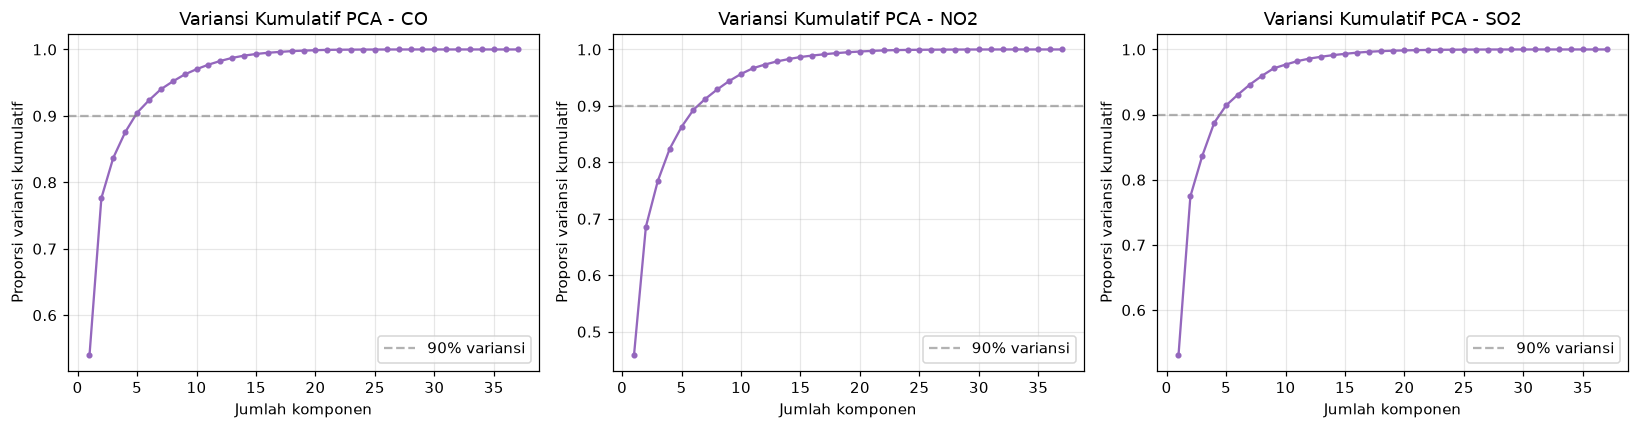

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (name, d) in zip(axes, processed.items()):
    cum = np.cumsum(d['pca_model'].explained_variance_ratio_)
    ax.plot(range(1, len(cum) + 1), cum, marker='.', color='tab:purple')
    ax.axhline(0.9, color='gray', linestyle='--', alpha=0.6, label='90% variansi')
    ax.set_title(f'Variansi Kumulatif PCA - {name}')
    ax.set_xlabel('Jumlah komponen')
    ax.set_ylabel('Proporsi variansi kumulatif')
    ax.legend()
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


## 7. Pencarian k Optimal — Data Setelah PCA (37 Komponen)

K-Means dijalankan pada ruang dimensi yang telah direduksi oleh PCA.
Grafik elbow dan silhouette score ditampilkan untuk masing-masing polutan.


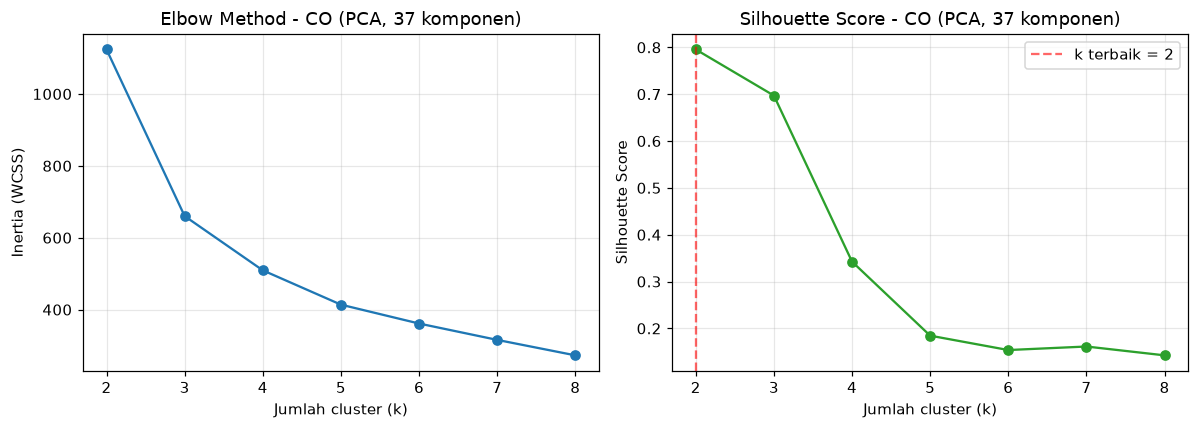

CO: k terbaik = 2  (silhouette = 0.795)



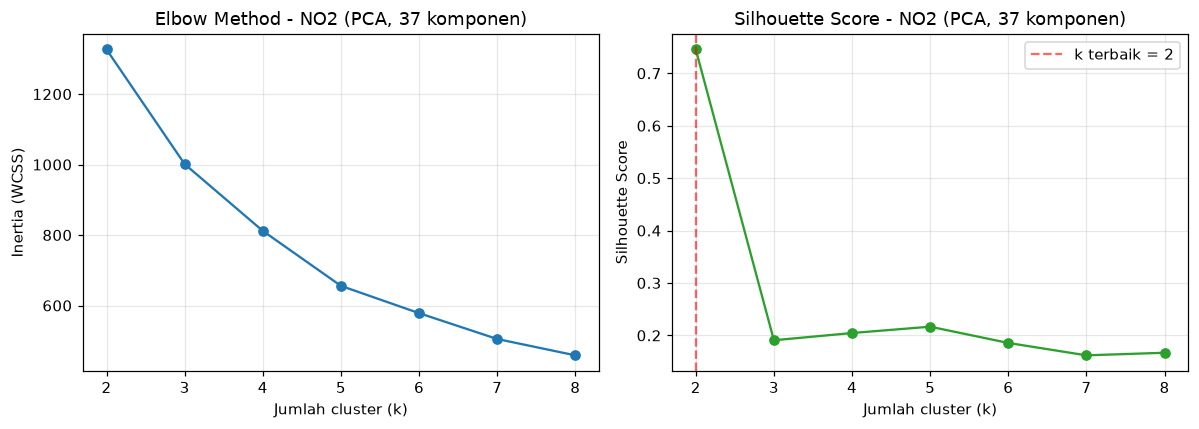

NO2: k terbaik = 2  (silhouette = 0.745)



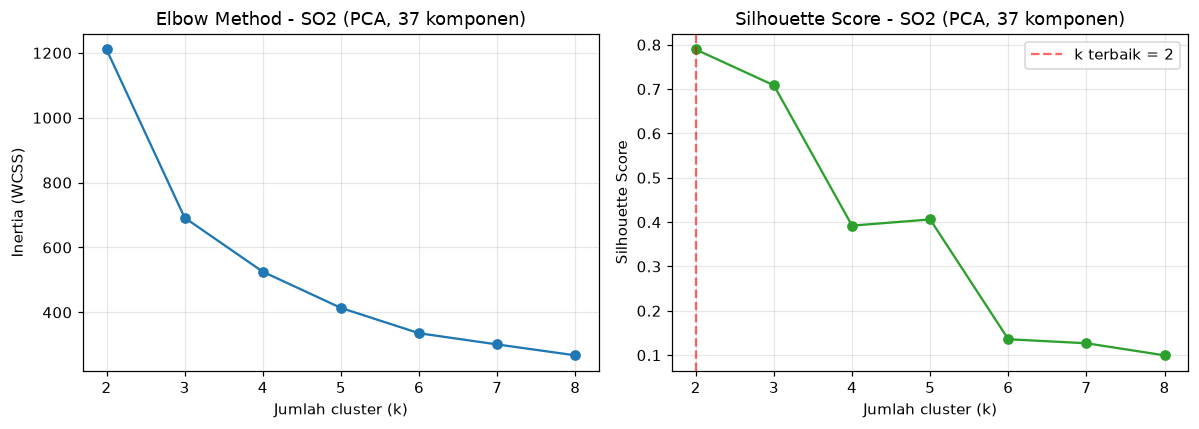

SO2: k terbaik = 2  (silhouette = 0.789)



In [7]:
pca_results = {}
for name, d in processed.items():
    res, k_best, sil_best = evaluate_k_range(d['X_pca'])
    pca_results[name] = (res, k_best, sil_best)
    plot_elbow_silhouette(res, f'{name} (PCA, {d["n_comp_actual"]} komponen)')
    print(f'{name}: k terbaik = {k_best}  (silhouette = {sil_best:.3f})\n')


## 8. Pencarian k Optimal — 68 Fitur Asli (Tanpa PCA)

Sebagai perbandingan, proses pencarian $k$ optimal diulang kali ini
pada data yang distandarisasi secara langsung tanpa reduksi dimensi PCA.
Ini untuk melihat apakah PCA mengubah kesimpulan tentang jumlah cluster terbaik.


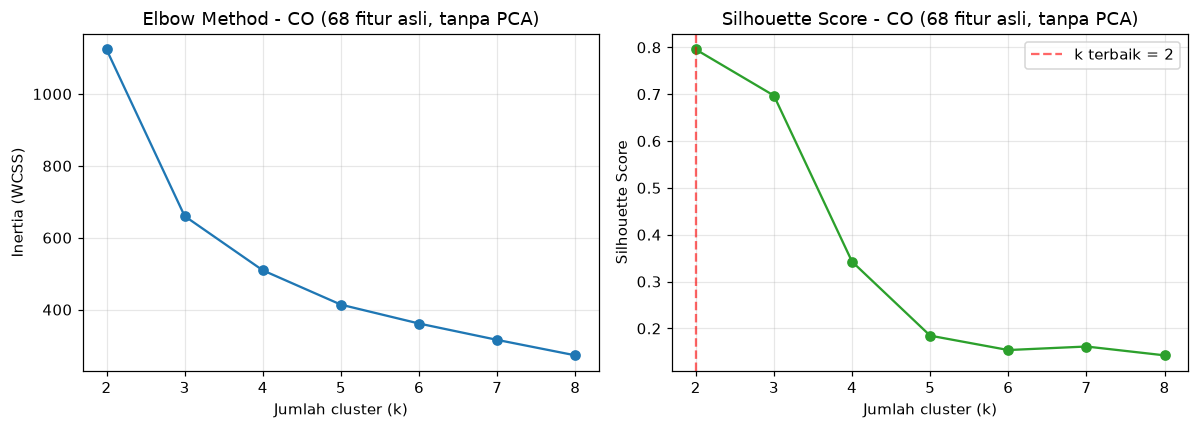

CO: k terbaik = 2  (silhouette = 0.795)



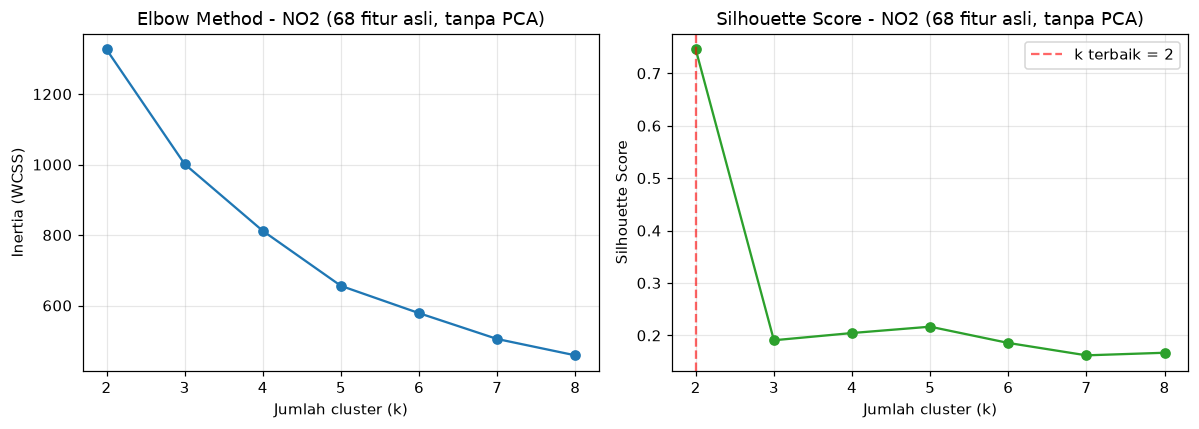

NO2: k terbaik = 2  (silhouette = 0.745)



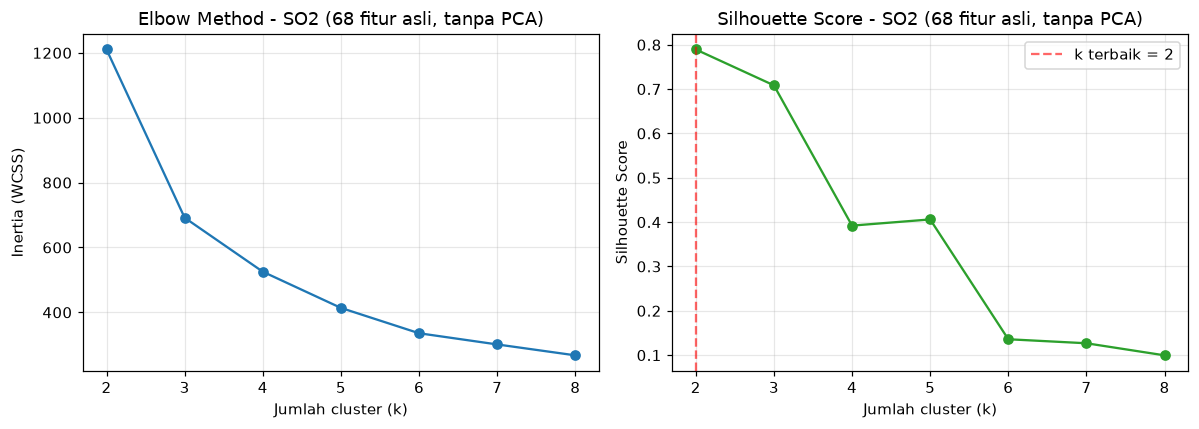

SO2: k terbaik = 2  (silhouette = 0.789)



In [8]:
full_results = {}
for name, d in processed.items():
    res, k_best, sil_best = evaluate_k_range(d['X_scaled'])
    full_results[name] = (res, k_best, sil_best)
    plot_elbow_silhouette(res, f'{name} (68 fitur asli, tanpa PCA)')
    print(f'{name}: k terbaik = {k_best}  (silhouette = {sil_best:.3f})\n')


## 9. Tabel Ringkasan: PCA (37 Komponen) vs. 68 Fitur Asli

Seluruh hasil dari kedua pendekatan dirangkum dalam satu tabel perbandingan
untuk memudahkan analisis lintas polutan.


In [9]:
summary_rows = []
for name, d in processed.items():
    _, k_pca, sil_pca = pca_results[name]
    _, k_full, sil_full = full_results[name]
    summary_rows.append({
        'Polutan': name,
        'n_sampel': d['X_scaled'].shape[0],
        'n_fitur_dipakai': d['X_scaled'].shape[1],
        'Hopkins': round(d['hopkins'], 3),
        'n_komponen_PCA': d['n_comp_actual'],
        'Var._dijelaskan_PCA (%)': round(d['cum_var'] * 100, 1),
        'k_terbaik (PCA)': k_pca,
        'Silhouette (PCA)': round(sil_pca, 3),
        'k_terbaik (68 fitur)': k_full,
        'Silhouette (68 fitur)': round(sil_full, 3),
    })

summary_df = pd.DataFrame(summary_rows)
summary_df


,Polutan,n_sampel,n_fitur_dipakai,Hopkins,n_komponen_PCA,Var._dijelaskan_PCA (%),k_terbaik (PCA),Silhouette (PCA),k_terbaik (68 fitur),Silhouette (68 fitur)
0,CO,37,65,0.880,37,100.0,2,0.795,2,0.795
1,NO2,37,66,0.842,37,100.0,2,0.745,2,0.745
2,SO2,37,66,0.886,37,100.0,2,0.789,2,0.789


## 10. Interpretasi dan Kesimpulan

**Acuan interpretasi Silhouette Score** berdasarkan Kaufman & Rousseeuw:

| Rentang skor | Kualitas struktur cluster |
|---|---|
| 0.71 - 1.00 | Struktur kuat (*strong*) |
| 0.51 - 0.70 | Struktur cukup (*reasonable*) |
| 0.26 - 0.50 | Struktur lemah (*weak*) |
| <= 0.25 | Tidak ada struktur yang bermakna |

---

### Hasil dan Pembahasan

Nilai **Hopkins Statistic** untuk ketiga polutan semuanya berada di atas 0.75,
yang mengonfirmasi bahwa data lokasi pengamatan memiliki **kecenderungan alami
untuk membentuk kelompok** — bukan sebaran acak.

| Polutan | Hopkins | Keterangan |
|---|:---:|---|
| CO | 0.880 | Kecenderungan cluster kuat |
| NO2 | 0.842 | Kecenderungan cluster kuat |
| SO2 | 0.886 | Kecenderungan cluster kuat |

Dari hasil evaluasi Elbow Method dan Silhouette Score, baik pada data hasil PCA
maupun 68 fitur asli, diperoleh **$k = 2$** sebagai jumlah cluster terbaik
untuk ketiga polutan secara konsisten.

| Polutan | Fitur aktif | k (PCA) | Silhouette (PCA) | k (68 fitur) | Silhouette (68 fitur) |
|---|:---:|:---:|:---:|:---:|:---:|
| CO | 65 | 2 | 0.795 | 2 | 0.795 |
| NO2 | 66 | 2 | 0.745 | 2 | 0.745 |
| SO2 | 66 | 2 | 0.789 | 2 | 0.789 |

Seluruh nilai silhouette berada pada rentang > 0.71, yang berarti
struktur dua cluster yang terbentuk tergolong **kuat** secara statistik.
Menariknya, hasil PCA dan 68 fitur asli menghasilkan silhouette yang identik,
menunjukkan bahwa proses reduksi dimensi tidak menghilangkan informasi
yang relevan untuk clustering.

**Kesimpulan:** Jumlah cluster optimal untuk K-Means pada data fitur kualitas udara
wilayah pengamatan adalah **$k = 2$** untuk polutan CO, NO2, maupun SO2.
Dua cluster ini kemungkinan mencerminkan perbedaan karakteristik pola konsentrasi
polutan antar wilayah — misalnya wilayah dengan paparan tinggi vs. rendah,
atau wilayah perkotaan vs. non-perkotaan.
